## Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm


import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))


from ml_force import MorrisLecar, MorrisLecarCurrent
from ml_force.utils import minmax_transform, z_transform

from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [3]:
def gen_noise(n_trials:int, dt, noise_amp:float=5.0, min_time:float=500.0, max_time:float=1000.0):
    noise_signal = []
    # Generate noise
    for i in range(n_trials):
        noise = np.random.uniform(-noise_amp, noise_amp, size=1)[0]
        duration = np.random.uniform(min_time, max_time, size=1)[0]
        nt_noise = int(duration/dt)
        noise_signal.extend([noise]*nt_noise)
    return np.array(noise_signal)

In [105]:
def gen_bifurcation_data(noise_signal:np.ndarray, dt:float=1e-1, tau:float=0.01, mu:float=3.0, x0:float=0.1):
    nt = noise_signal.shape[0]
    x = x0
    x_rec = np.zeros((nt, 1))
        
    for i in tqdm(range(nt)):
        x_dot = mu * x - (x**3) + noise_signal[i]
        x += x_dot * dt * tau
        x_rec[i, 0] = x
    return x_rec

In [107]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)


dt = 1e-1

# Generate noise
noise = gen_noise(n_trials=60, dt=dt, noise_amp=2.0, min_time=500.0, max_time=1000.0)
x = gen_bifurcation_data(noise, dt=dt, tau=0.02, mu=2., x0=0.1)

sup = minmax_transform(x, zero_mean=True)
print(sup.shape)

noise_signal = minmax_transform(noise, zero_mean=True)

nt = sup.shape[0]
T = nt * dt
time = np.arange(0, T, dt)

100%|██████████| 463478/463478 [00:00<00:00, 1934394.31it/s]

(463478, 1)


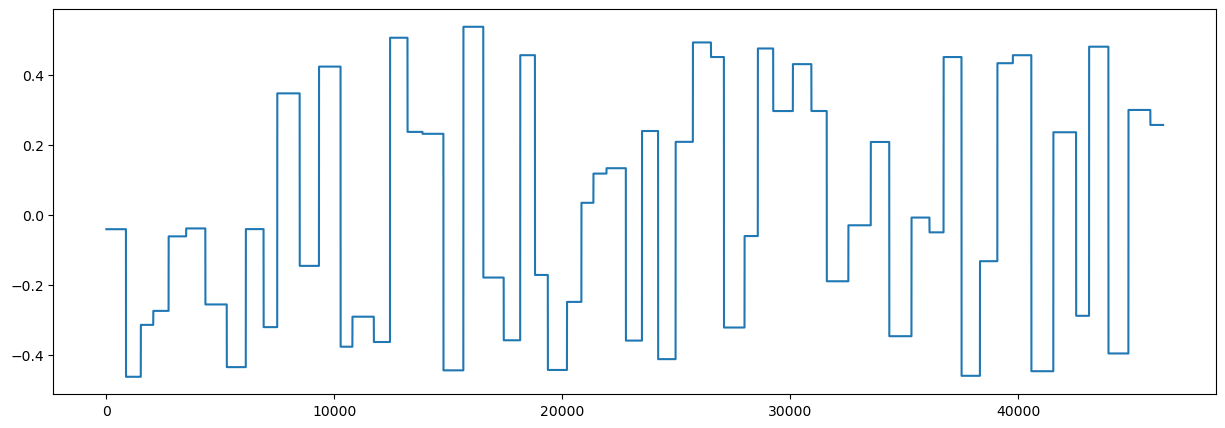

In [108]:
fig = plt.figure(figsize=(15, 5))
plt.plot(time, noise_signal)
plt.show()

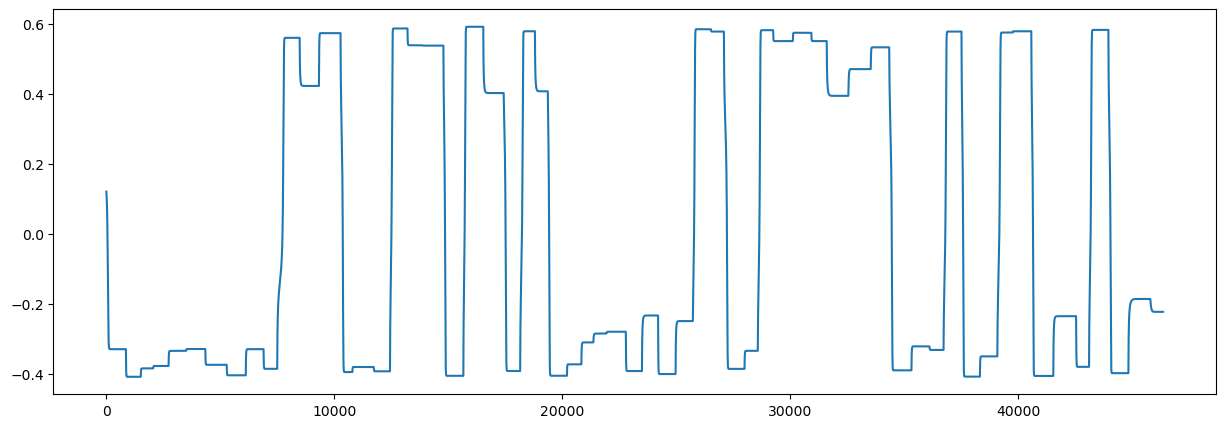

In [109]:
plt.figure(figsize=(15, 5))
plt.plot(time, sup[:, 0])
plt.show()

# ML Conductance-based Model

In [110]:
NE = 800
NI = 200
N = NI + NE

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")

# input current for I and E neurons
Ie = 65     # pA
Ii = 65     # pA
current = np.array([Ie] * NE + [Ii] * NI).reshape(N, 1)
current_tensor = torch.tensor(current, dtype=torch.float32).to(device)
noise_tensor = torch.tensor(noise_signal, dtype=torch.float32).to(device)

Q = 100
lamda = 1.
gbar = 20
sparse = 0.01

Using Device <cuda> for PyTorch computations...



In [111]:
torch.cuda.random.manual_seed(seed)
ml = None
try:
    ml = MorrisLecarCurrent(supervisor=sup, BIAS=current, T=T, dt=dt, 
                            p_sparsity=sparse,
                            Ne=NE, Ni=NI, Q=Q, gbar=gbar, ridge_coeff=lamda, device=device,
                            )
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

In [112]:
# colors = plt.pcolormesh(ml.w.cpu().numpy(), cmap='viridis')
# plt.colorbar(colors)
# plt.show()

print(f"Mean: {ml.w.type(dtype=torch.float64).mean().item()}, \nSTD: {ml.w.type(dtype=torch.float64).std().item()}")
print(f"Max: {ml.w.type(dtype=torch.float64).max().item()}, \nMin: {ml.w.type(dtype=torch.float64).min().item()}")

Mean: 0.000513665456126561, 
STD: 0.31608837220358044
Max: 1.512953519821167, 
Min: -1.5671961307525635


In [113]:
eta = Q * (2 * torch.rand((ml._N, sup.shape[1]), device=device, dtype=torch.float32) - 1)

In [114]:
# RLS params
# rls_stop = round(T * .6)
rls_start = 500
test_time = T * .5    # ms
rls_stop = T - test_time
rls_step = 5

memory_length = 5000    # ms
rls_gap = rls_step * dt
memory_coeff = memory_length / rls_gap
ff_coeff = 1 - 1 / memory_coeff

# ff_coeff = 1
ff_coeff

0.9999

In [115]:
save_path = os.path.join(os.getcwd(), "bifurcation_task", f"Q_{Q}_gbar_{gbar}_l_{lamda}_Ne_{NE}_Ni_{NI}")
os.makedirs(save_path, exist_ok=True)

def save_tensor(tensor, name):
    file_name = name + ".pt"
    torch.save(tensor, os.path.join(save_path, file_name))
    print(f"Saved {file_name} in {save_path}")

In [116]:
def load_tensor(save_path:str, name:str):
    file_name = os.path.join(save_path, name + ".pt")
    tensor = torch.load(os.path.join(save_path, file_name))
    print(f"Loaded {file_name} from {save_path}")
    return tensor

In [117]:
duration = 500
nt_transient = int(duration // dt)

n_neurons = 10
neurons = np.random.choice(N, n_neurons, replace=False)
print(neurons)

ml._BIAS = current_tensor
print(f"Transient Period: {duration} ms")
for i in tqdm(range(nt_transient)):
    ml.euler_step()

nt_train = int((T-test_time) // dt)
s_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
v_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
n_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
xhat_rec_train = torch.zeros((nt_train, sup.shape[1]), device=device, dtype=torch.float32)
dec_rec_train = torch.zeros((nt_train, n_neurons, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Training Period: {T-test_time} ms")
for i in tqdm(range(nt_train)):
    ml._BIAS = current_tensor + eta @ noise_tensor[i].reshape(-1, 1)
    ml.euler_step()
    s_rec_train[i] = ml.s[neurons].ravel()
    v_rec_train[i] = ml.v[neurons].ravel()
    n_rec_train[i] = ml.n[neurons].ravel()
    xhat_rec_train[i] = ml.x_hat.ravel()
    dec_rec_train[i] = ml.dec[neurons]

    if i <= int(rls_stop // dt) and i % rls_step == 0:
        # ml.rls_ff(i, ff_coeff=ff_coeff)
        ml.rls(i)

[370 580 480 905 561  47  81 749 248 886]
Transient Period: 500 ms


100%|██████████| 4999/4999 [00:01<00:00, 3380.63it/s]


Training Period: 23173.9 ms


100%|██████████| 231739/231739 [01:52<00:00, 2068.77it/s]


In [118]:
save_tensor(ml.w, "weights")
save_tensor(s_rec_train, "s_rec_train")
save_tensor(v_rec_train, "v_rec_train")
save_tensor(n_rec_train, "n_rec_train")
save_tensor(xhat_rec_train, "xhat_rec_train")
save_tensor(dec_rec_train, "dec_rec_train")

Saved weights.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved s_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved v_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved n_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved xhat_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved dec_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200


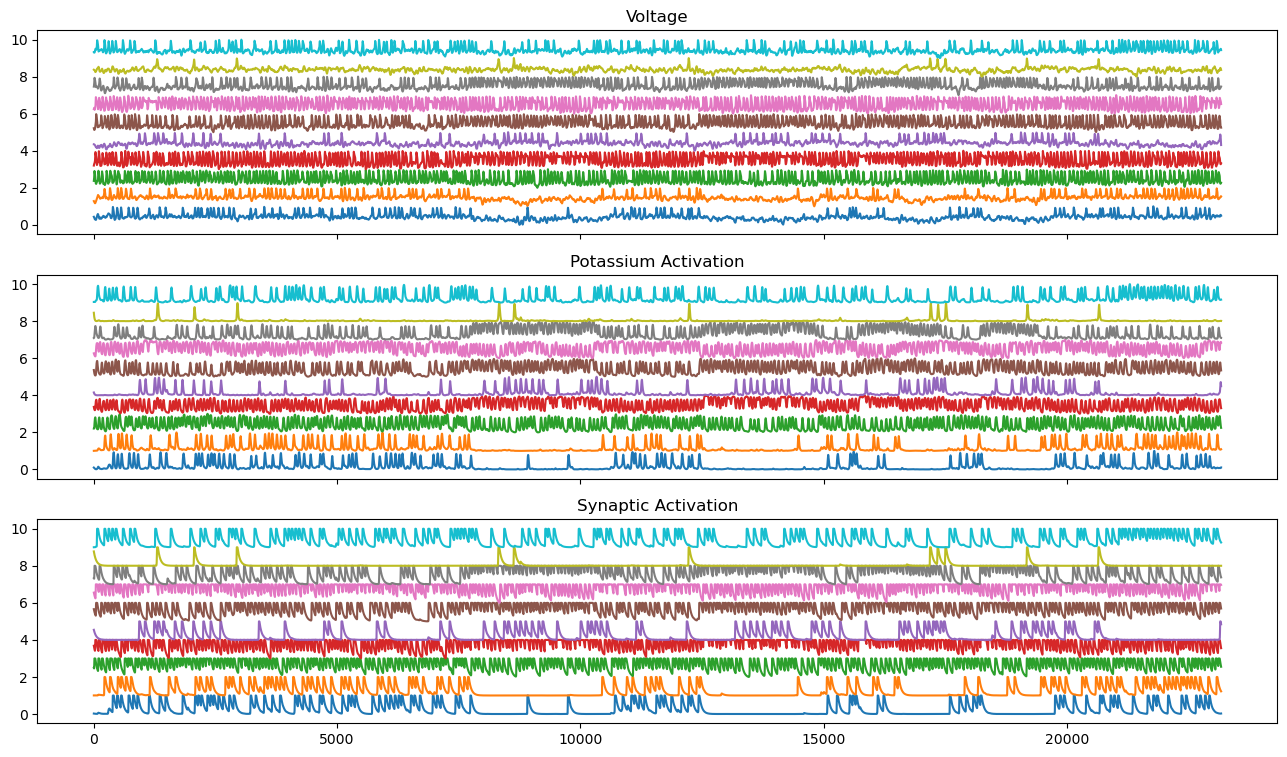

In [119]:
t_train = np.arange(nt_train) * dt

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_train, minmax_transform(v_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_train, minmax_transform(n_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_train, minmax_transform(s_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

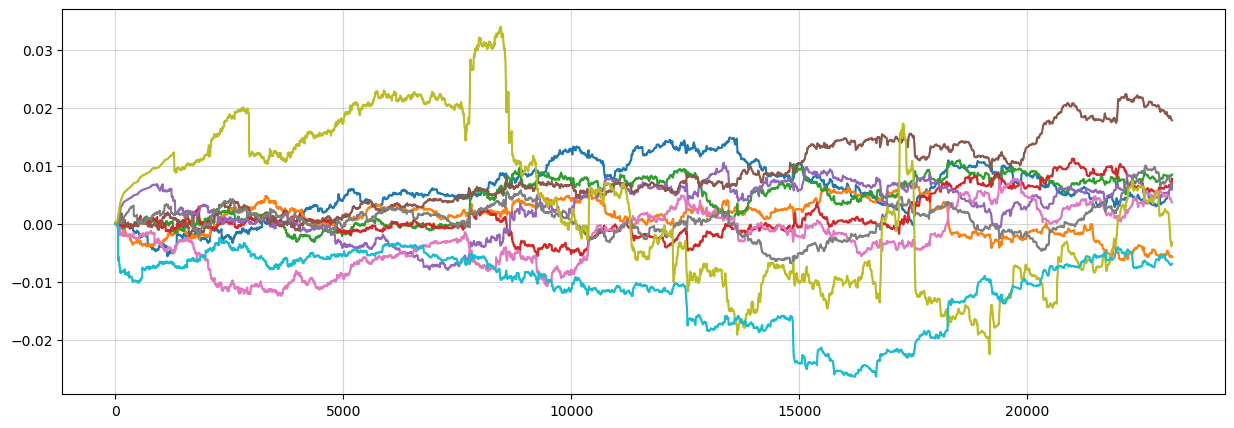

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

ax.plot(t_train, dec_rec_train[:, :, 0].cpu().numpy())
ax.grid(alpha=0.5)
plt.show()

In [121]:
ml.dec.abs().max().item()

0.4408210217952728

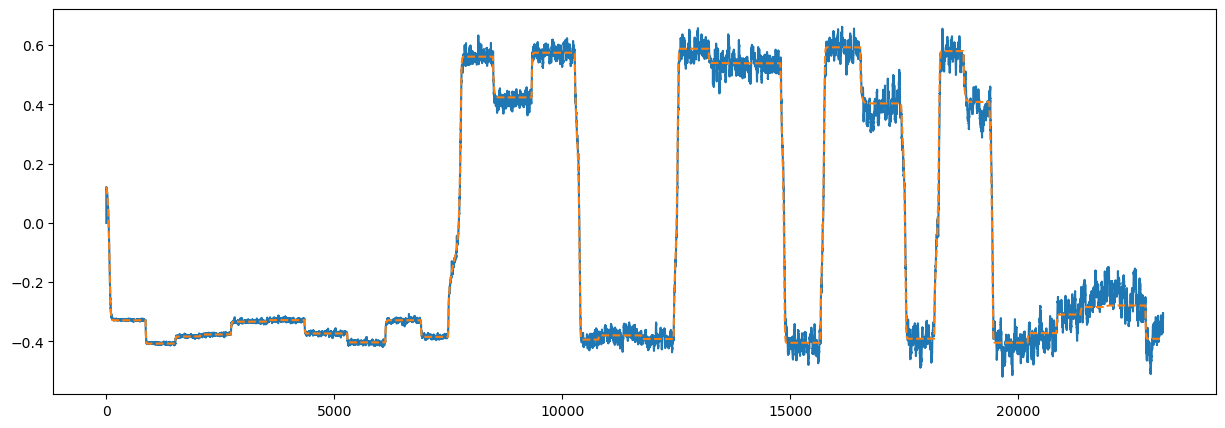

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5), sharex=True)
ax.plot(t_train, xhat_rec_train[:, 0].cpu().numpy())
ax.plot(t_train, sup[:nt_train, 0], '--')
plt.show()

In [123]:
nt_test = nt - nt_train
s_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
v_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
n_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
x_hat_rec = torch.zeros((nt_test, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Testing Period: {test_time} ms")
for i in tqdm(range(nt_test)):
    ml._BIAS = current_tensor + eta @ noise_tensor[i + nt_train].reshape(-1, 1)
    ml.euler_step()
    s_rec_test[i] = ml.s[neurons].ravel()
    v_rec_test[i] = ml.v[neurons].ravel()
    n_rec_test[i] = ml.n[neurons].ravel()
    x_hat_rec[i] = ml.x_hat.ravel()

Testing Period: 23173.9 ms


100%|██████████| 231739/231739 [01:36<00:00, 2402.49it/s]


In [124]:
save_tensor(s_rec_test, "s_rec_test")
save_tensor(v_rec_test, "v_rec_test")
save_tensor(n_rec_test, "n_rec_test")
save_tensor(x_hat_rec, "x_hat_rec")

Saved s_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved v_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved n_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Saved x_hat_rec.pt in /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200


In [125]:
s_rec_test = load_tensor(save_path, "s_rec_test")
v_rec_test = load_tensor(save_path, "v_rec_test")
n_rec_test = load_tensor(save_path, "n_rec_test")
x_hat_rec = load_tensor(save_path, "x_hat_rec")

Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200/s_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200/v_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200/n_rec_test.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200/x_hat_rec.pt from /home/ali/Code/research/ml_force_research/morris_lecar/bifurcation_task/Q_100_gbar_20_l_1.0_Ne_800_Ni_200


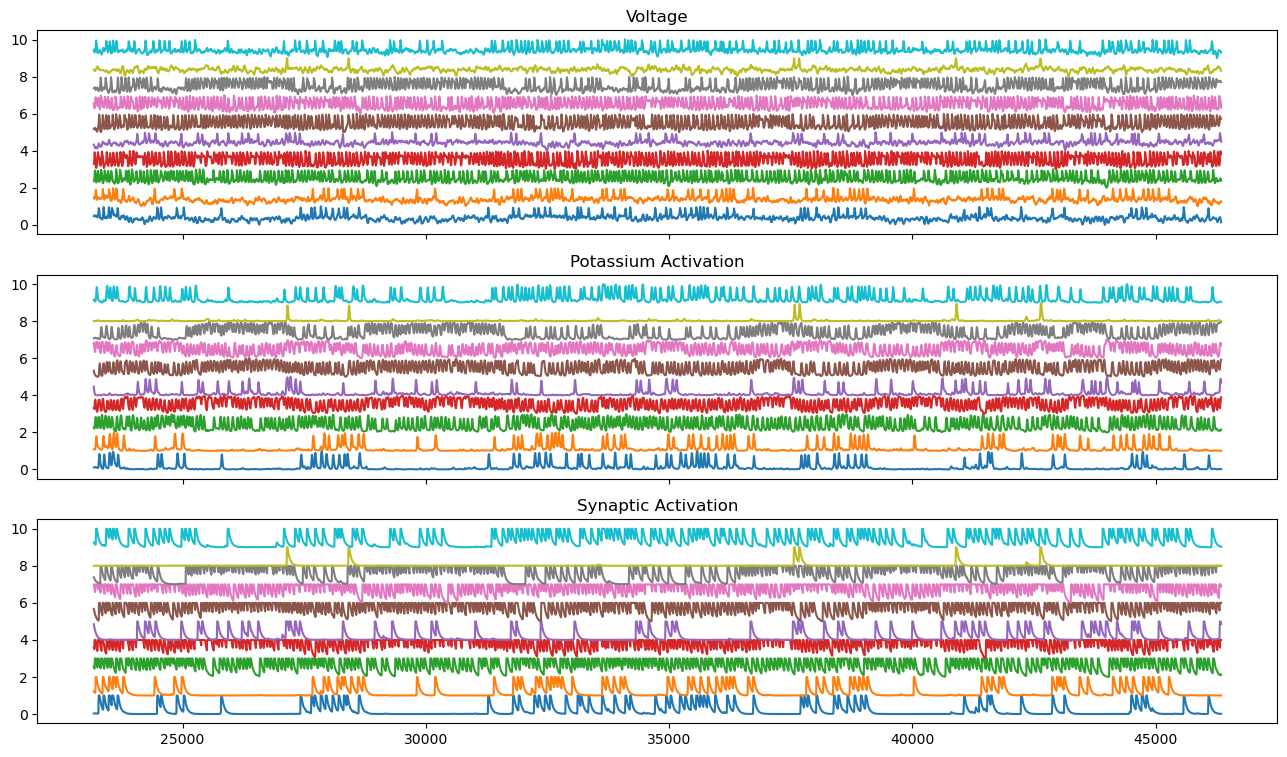

In [126]:
nt_test = s_rec_test.shape[0]
t_test = np.arange(nt_test) * dt + T - test_time
n_neurons = s_rec_test.shape[1]

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_test, minmax_transform(v_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_test, minmax_transform(n_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_test, minmax_transform(s_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

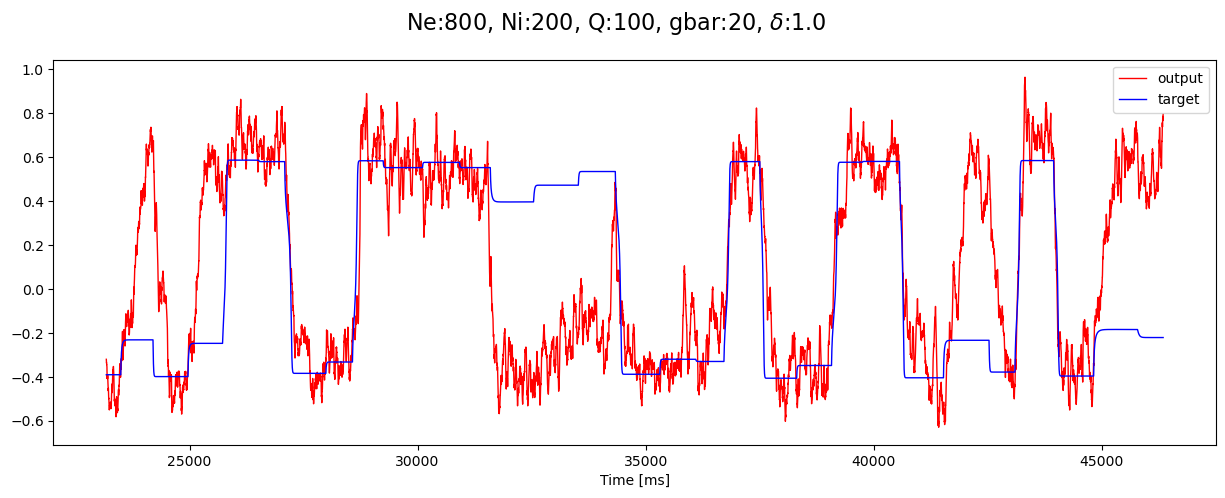

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5), sharex=True)
ax.plot(t_test, x_hat_rec[:, 0].cpu().numpy(), 'r-', lw=1, label='output')
ax.plot(t_test, ml.sup[-nt_test:, 0].cpu().numpy(), 'b-', lw=1, label='target')
# ax.set_title(f"Test phase, axis: {0}")
ax.legend(loc='upper right')
plt.xlabel('Time [ms]')
plt.suptitle(fr"Ne:{NE}, Ni:{NI}, Q:{Q}, gbar:{gbar}, $\delta$:{lamda}", fontsize=16)
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_timeseries.png"), dpi=300, bbox_inches='tight')
plt.show()